# R2 vs n_components Plot


In [1]:
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import io

# Add workspace root to path so msca is importable
sys.path.insert(0, os.path.abspath("../../.."))
from msca import *
from msca.evaluations import evaluate_trial_average_MLP, evaluate_trial_average_Linear

# Re-import explicitly after wildcard imports to avoid namespace collisions
from sklearn.model_selection import KFold


## Load Data


In [2]:
def load_data(dir_path, f):
    mat_file = io.loadmat(dir_path + f)
    data_array = mat_file["data"]
    mask = mat_file["mask"]
    start_idxs = mat_file["mask"]["firstTimeEachCond"][0][0].squeeze() - 1
    end_idxs = mat_file["mask"]["lastTimeEachCond"][0][0].squeeze()
    return data_array, mask, start_idxs, end_idxs


def preprocess(data_array, start_idxs, end_idxs, downsample_factor=5):
    if downsample_factor is not None:
        data_downsamp = data_array[::downsample_factor]
        start_idxs = start_idxs // downsample_factor
        end_idxs = end_idxs // downsample_factor
    else:
        data_downsamp = data_array

    data_concat = data_downsamp.T
    fr_range = np.ptp(data_concat, axis=1)[:, None]
    data_norm = data_concat / (fr_range + 5)
    data_snm_norm = data_norm - np.mean(data_norm, axis=1)[:, None]
    fit_data = np.copy(data_snm_norm.T)
    split_data = [fit_data[i:j] for i, j in zip(start_idxs, end_idxs)]
    return split_data


# Paths (relative to the notebook directory in experiments/cycling/)
fp = "./data/"


m1_data, m1_mask, m1_start_idxs, m1_end_idxs = load_data(fp, "Cousteau_interp_cycling_m1_rawRates.mat")
sma_data, sma_mask, sma_start_idxs, sma_end_idxs = load_data(fp, "Cousteau_interp_cycling_sma_rawRates.mat")

m1_preprocessed = preprocess(m1_data, m1_start_idxs, m1_end_idxs, downsample_factor=5)
sma_preprocessed = preprocess(sma_data, sma_start_idxs, sma_end_idxs, downsample_factor=5)

X = {"M1": m1_preprocessed, "SMA": sma_preprocessed}

print(f"M1:  {len(m1_preprocessed)} trials, {m1_preprocessed[0].shape[1]} neurons")
print(f"SMA: {len(sma_preprocessed)} trials, {sma_preprocessed[0].shape[1]} neurons")


M1:  20 trials, 116 neurons
SMA: 20 trials, 77 neurons


## Load Saved Neuron Split Indices




In [3]:
# nonlinear nonlinear
experiment_path = "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5/"

train_split_path = os.path.join(experiment_path, "n_train_splits.pt")
test_split_path  = os.path.join(experiment_path, "n_test_splits.pt")

train_idxs = torch.load(train_split_path, weights_only=False)
test_idxs  = torch.load(test_split_path, weights_only=False)

n_folds = len(train_idxs[list(train_idxs.keys())[0]])
print(f"Number of folds: {n_folds}")
for k in train_idxs:
    print(f"  {k}:  train neurons per fold = {[len(t) for t in train_idxs[k]]}, "
          f"test neurons per fold = {[len(t) for t in test_idxs[k]]}")


Number of folds: 5
  M1:  train neurons per fold = [92, 93, 93, 93, 93], test neurons per fold = [24, 23, 23, 23, 23]
  SMA:  train neurons per fold = [61, 61, 62, 62, 62], test neurons per fold = [16, 16, 15, 15, 15]


# R2 vs components for three models with MLP fitting
This section computes held-out-neuron R2 for each n_components value.

For each n_components in [10, 16, 26, 36, 46, 50]:
- Load each available split model from `results/.../n_components_{n}/msca_split_{i}.pt`
- Build `X_train` and `X_val` from the saved neuron splits
- Evaluate with `evaluate_trial_average_MLP(msca, X_train, X_val, n_splits=5)`

Models:
- nonlinear + nonlinear
- nonlinear + linear 
- linear + linear 


=== Linear Encoder + Linear Decoder ===
Using folder: ./results/bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5/
  n_components=6
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.835264012619529, 'SMA': 1.2456809874900292}
Using lam_sparse = 0.6662639833074178
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.8807947440764428
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7790460614814678, 'SMA': 1.3959094375772194}
Hidden Layer Size for MLP:
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 0: mean R² = 0.3855
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.8156891749668416, 'SMA': 1.2919181898658985}
Using lam_sparse = 0.6641857917098428
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.8607202210590528
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7651728543154294, 'SMA': 1.4427812686385277}
Hidden Layer Size for MLP:
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 1: mean R² = 0.4529
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.8194023689676773, 'SMA': 1.2827117901724123}
Using lam_sparse = 0.6603134556863604
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.8740918767524357
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7575484939042035, 'SMA': 1.470690980212017}
Hidden Layer Size for MLP:
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155


...

    fold 2: mean R² = 0.8171
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7659258877190617, 'SMA': 1.4401115556831887}
Using lam_sparse = 0.06145999566031179
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.06145999566031179
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7659258877190617, 'SMA': 1.4401115556831887}
Hidden Layer Size for MLP:
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 3: mean R² = 0.8127
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.8033694853401256, 'SMA': 1.324077608595703}
Using lam_sparse = 0.060114075340989045
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.060114075340989045
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.8033694853401256, 'SMA': 1.324077608595703}
Hidden Layer Size for MLP:
inside evaluate_trial_average_MLP
hidden layer size for all regions: 155


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 4: mean R² = 0.7767


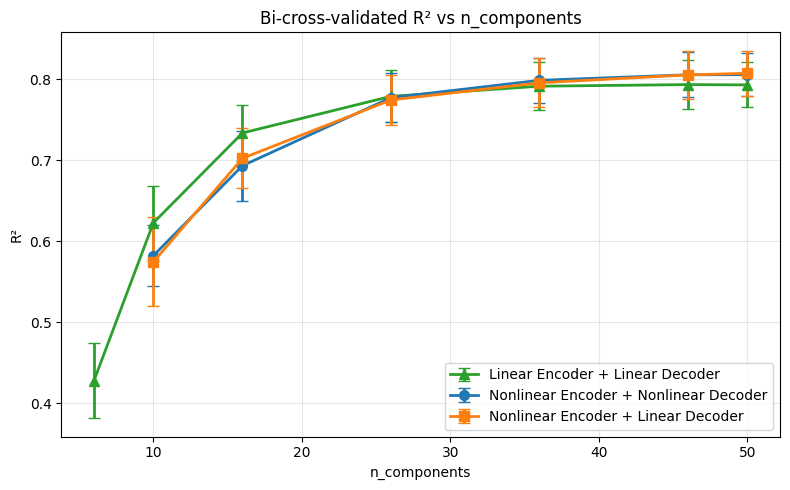


Summary:
- Linear Encoder + Linear Decoder
    n_components=6: mean=0.4278, std=0.0464, n_scores=25
    n_components=10: mean=0.6226, std=0.0460, n_scores=25
    n_components=16: mean=0.7335, std=0.0348, n_scores=25
    n_components=26: mean=0.7787, std=0.0322, n_scores=25
    n_components=36: mean=0.7912, std=0.0298, n_scores=25
    n_components=46: mean=0.7932, std=0.0297, n_scores=25
    n_components=50: mean=0.7928, std=0.0278, n_scores=25
- Nonlinear Encoder + Nonlinear Decoder
    n_components=10: mean=0.5822, std=0.0376, n_scores=25
    n_components=16: mean=0.6931, std=0.0431, n_scores=25
    n_components=26: mean=0.7770, std=0.0299, n_scores=25
    n_components=36: mean=0.7985, std=0.0279, n_scores=25
    n_components=46: mean=0.8053, std=0.0278, n_scores=25
    n_components=50: mean=0.8055, std=0.0268, n_scores=25
- Nonlinear Encoder + Linear Decoder
    n_components=10: mean=0.5745, std=0.0550, n_scores=25
    n_components=16: mean=0.7023, std=0.0368, n_scores=25
    n_comp

In [ ]:
experiment_configs = [
    {
        # This is the configuration for the linear encoder + linear decoder model
        # the candidate_paths list contains the paths to the results of the experiments for this model

        "label": "Linear Encoder + Linear Decoder",

        "candidate_paths": [

            "./results/bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5/",

        

        ],

        "plot_kwargs": {"color": "tab:green", "marker": "^"},

        "model_kwargs": {

            "linear": True,

            "filter_len": 21,

            "decoder_type": "linear",

        },

    },
    # This is the configuration for the nonlinear encoder + nonlinear decoder model

    {

        "label": "Nonlinear Encoder + Nonlinear Decoder",

        "candidate_paths": [

            "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5/",

        ],

        "plot_kwargs": {"color": "tab:blue", "marker": "o"},

        "model_kwargs": {

            "linear": False,

            "filter_len": 21,

            "decoder_type": "nonlinear",

            "decoder_activation": "GeLU",

            "decoder_init_mode": "pca",

            "init": "unique",

        },

    },
    # This is the configuration for the nonlinear encoder + linear decoder model

    {

        "label": "Nonlinear Encoder + Linear Decoder",

        "candidate_paths": [

            "./results/bi-cross-validation-Cousteau-nonlinear-linear-lamsparse-2.5/",

        ],

        "plot_kwargs": {"color": "tab:orange", "marker": "s"},

        "model_kwargs": {

            "linear": False,

            "filter_len": 21,

            "decoder_type": "linear",

            "init": "unique",

        },

    },

    

]





def resolve_experiment_path(candidate_paths):

    for path in candidate_paths:

        if os.path.isdir(path):

            return path

    return None





def discover_component_dirs(experiment_root):

    component_dirs = []

    for name in os.listdir(experiment_root):

        path = os.path.join(experiment_root, name)

        if not os.path.isdir(path):

            continue

        if not name.startswith("n_components_"):

            continue

        try:

            n_components = int(name.split("_")[-1])

        except ValueError:

            continue

        component_dirs.append((n_components, path))

    return sorted(component_dirs, key=lambda x: x[0])





def build_model(n_components, model_kwargs):

    kwargs = {

        "n_components": n_components,

        "loss_func": "Gaussian",

        "lam_sparse": 2.5,

        "lam_orthog": 0.0,

        "lam_region": 0.0,

        "cd_rate": 0.5,

        "cd_mode": "both",

    }

    kwargs.update(model_kwargs) # encoder type has been set in model_kwargs

    if kwargs.get("decoder_type", "linear").lower() == "nonlinear":

        kwargs.setdefault("decoder_hidden_size", n_components)

        kwargs.setdefault("decoder_activation", "GeLU")

        kwargs.setdefault("decoder_init_mode", "pca")

    return mSCA(**kwargs)





def evaluate_component_sweep(config):

    experiment_root = resolve_experiment_path(config["candidate_paths"])

    if experiment_root is None:

        print(f"[skip] {config['label']}: no experiment folder found.")

        return {}



    print(f"\n=== {config['label']} ===")

    print(f"Using folder: {experiment_root}")



    train_split_path = os.path.join(experiment_root, "n_train_splits.pt")

    test_split_path = os.path.join(experiment_root, "n_test_splits.pt")

    if not (os.path.exists(train_split_path) and os.path.exists(test_split_path)):

        print("  [skip] missing saved neuron split files.")

        return {}



    train_idxs = torch.load(train_split_path, weights_only=False)

    test_idxs = torch.load(test_split_path, weights_only=False)

    k0 = list(train_idxs.keys())[0]

    n_folds = len(train_idxs[k0])



    component_dirs = discover_component_dirs(experiment_root)

    if len(component_dirs) == 0:

        print("  [skip] no n_components_* subdirectories found, so no curve can be drawn.")

        return {}



    results = {}

    for n_components, model_dir in component_dirs:

        print(f"  n_components={n_components}")

        all_scores = []

        used_folds = []



        for i in range(n_folds):

            model_path_candidates = [

                os.path.join(model_dir, f"msca_split_{i}.pt"),

                os.path.join(model_dir, f"msca_{i}.pt"),

            ]

            model_path = next((p for p in model_path_candidates if os.path.exists(p)), None)

            if model_path is None:

                print(f"    [skip] missing model for fold {i}")

                continue



            X_train = {

                k: [trial[:, train_idxs[k][i]] for trial in v]

                for k, v in X.items()

            }

            X_val = {

                k: [trial[:, test_idxs[k][i]] for trial in v]

                for k, v in X.items()

            }



            try:

                msca_model = build_model(n_components, config["model_kwargs"])

                msca_model.load(model_path, X_train)
                # using the evaluate_trial_average_MLP function to evaluate the model on the validation set
                # MLP fitting 
                print("Hidden Layer Size for MLP:")
                fold_scores = evaluate_trial_average_MLP(

                    msca_model,

                    X_train,

                    X_val,

                    n_splits=5,

                )

            except Exception as exc:

                print(f"    [skip] fold {i} failed: {exc}")

                continue



            fold_scores = np.asarray(fold_scores, dtype=float)

            all_scores.extend(fold_scores.tolist())

            used_folds.append(i)

            print(f"    fold {i}: mean R² = {fold_scores.mean():.4f}")



        if len(all_scores) == 0:

            print("    [warn] no valid scores collected for this n_components.")

            continue



        all_scores = np.asarray(all_scores, dtype=float)

        results[n_components] = {

            "scores": all_scores,

            "mean": float(all_scores.mean()),

            "std": float(all_scores.std()),

            "n_scores": int(len(all_scores)),

            "used_folds": used_folds,

        }



    return results





comparison_results = {

    config["label"]: evaluate_component_sweep(config)

    for config in experiment_configs

}


# Plotting the R² vs n_components curves for each model configuration

plt.figure(figsize=(8, 5))

n_curves = 0



for config in experiment_configs:

    label = config["label"]

    results = comparison_results[label]

    valid_n = sorted(results.keys())

    if len(valid_n) == 0:

        continue



    mean_r2 = np.array([results[n]["mean"] for n in valid_n], dtype=float)

    std_r2 = np.array([results[n]["std"] for n in valid_n], dtype=float)

    plt.errorbar(

        valid_n,

        mean_r2,

        yerr=std_r2,

        linestyle="-",

        linewidth=2,

        markersize=7,

        capsize=4,

        label=label,

        **config["plot_kwargs"],

    )

    n_curves += 1



if n_curves == 0:

    print("No valid experiment results were found. Check that the result folders and saved split/model files exist.")

else:

    plt.xlabel("n_components")

    plt.ylabel("R²")

    plt.title("Bi-cross-validated R² vs n_components")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()



    print("\nSummary:")

    for config in experiment_configs:

        label = config["label"]

        results = comparison_results[label]

        if len(results) == 0:

            print(f"- {label}: no valid results")

            continue

        print(f"- {label}")

        for n_components in sorted(results.keys()):

            r = results[n_components]

            print(

                f"    n_components={n_components}: mean={r['mean']:.4f}, "

                f"std={r['std']:.4f}, n_scores={r['n_scores']}"

            )


# R2 vs components for three models with Linear Regression  fitting
- nonlinear + nonlinear
- nonlinear + linear 
- linear + linear 


=== Linear Encoder + Linear Decoder ===
Using folder: ./results/bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5/
  n_components=6
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.835264012619529, 'SMA': 1.2456809874900292}
Using lam_sparse = 0.6662639833074178
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.8807947440764428
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7790460614814678, 'SMA': 1.3959094375772194}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 0: mean R² = 0.3042
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.8156891749668416, 'SMA': 1.2919181898658985}
Using lam_sparse = 0.6641857917098428
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.8607202210590528
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7651728543154294, 'SMA': 1.4427812686385277}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 1: mean R² = 0.3868
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.8194023689676773, 'SMA': 1.2827117901724123}
Using lam_sparse = 0.6603134556863604
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.8740918767524357
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7575484939042035, 'SMA': 1.470690980212017}


...

    fold 2: mean R² = 0.7821
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.7659258877190617, 'SMA': 1.4401115556831887}
Using lam_sparse = 0.06145999566031179
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.06145999566031179
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.7659258877190617, 'SMA': 1.4401115556831887}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 3: mean R² = 0.7849
Initialized mSCA with lam_sparse=2.5, lam_orthog=0.0, lam_region=0.0
passed lam_sparse: 2.5
passed lam_orthog: 0.0
Using region-weights = {'M1': 0.8033694853401256, 'SMA': 1.324077608595703}
Using lam_sparse = 0.060114075340989045
Using lam_orthog = 0.0
Using lam_region = 0.0
Checkpoint training hyperparameters:
  lam_sparse  = 0.060114075340989045
  lam_orthog  = 0.0
  lam_region  = 0.0
  region_weights = {'M1': 0.8033694853401256, 'SMA': 1.324077608595703}


/Users/shiyuexu/Documents/AAA-mSCA Research/mSCA_Real/mSCA/msca/architectures.py:168: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.model.weight = torch.tensor(V_combined, dtype=torch.float32)


    fold 4: mean R² = 0.7463


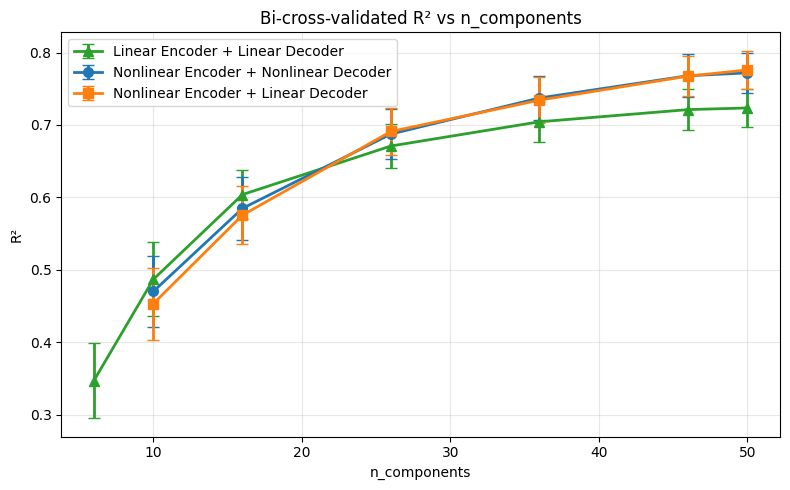


Summary:
- Linear Encoder + Linear Decoder
    n_components=6: mean=0.3474, std=0.0522, n_scores=25
    n_components=10: mean=0.4871, std=0.0509, n_scores=25
    n_components=16: mean=0.6040, std=0.0341, n_scores=25
    n_components=26: mean=0.6710, std=0.0302, n_scores=25
    n_components=36: mean=0.7044, std=0.0277, n_scores=25
    n_components=46: mean=0.7212, std=0.0282, n_scores=25
    n_components=50: mean=0.7235, std=0.0265, n_scores=25
- Nonlinear Encoder + Nonlinear Decoder
    n_components=10: mean=0.4704, std=0.0490, n_scores=25
    n_components=16: mean=0.5849, std=0.0430, n_scores=25
    n_components=26: mean=0.6875, std=0.0347, n_scores=25
    n_components=36: mean=0.7372, std=0.0299, n_scores=25
    n_components=46: mean=0.7680, std=0.0294, n_scores=25
    n_components=50: mean=0.7719, std=0.0280, n_scores=25
- Nonlinear Encoder + Linear Decoder
    n_components=10: mean=0.4535, std=0.0496, n_scores=25
    n_components=16: mean=0.5757, std=0.0403, n_scores=25
    n_comp

In [ ]:
# Compare three model families on the same R² vs n_components plot

experiment_configs = [
    {

        "label": "Linear Encoder + Linear Decoder",

        "candidate_paths": [

            "./results/bi-cross-validation-Cousteau-linear-linear-lamsparse-2.5/",

        

        ],

        "plot_kwargs": {"color": "tab:green", "marker": "^"},

        "model_kwargs": {

            "linear": True,

            "filter_len": 21,

            "decoder_type": "linear",

        },

    },

    {

        "label": "Nonlinear Encoder + Nonlinear Decoder",

        "candidate_paths": [

            "./results/bi-cross-validation-Cousteau-nonlinear-nonlinear-lamsparse-2.5/",

        ],

        "plot_kwargs": {"color": "tab:blue", "marker": "o"},

        "model_kwargs": {

            "linear": False,

            "filter_len": 21,

            "decoder_type": "nonlinear",

            "decoder_activation": "GeLU",

            "decoder_init_mode": "pca",

            "init": "unique",

        },

    },

    {

        "label": "Nonlinear Encoder + Linear Decoder",

        "candidate_paths": [

            "./results/bi-cross-validation-Cousteau-nonlinear-linear-lamsparse-2.5/",

        ],

        "plot_kwargs": {"color": "tab:orange", "marker": "s"},

        "model_kwargs": {

            "linear": False,

            "filter_len": 21,

            "decoder_type": "linear",

            "init": "unique",

        },

    },



]





def resolve_experiment_path(candidate_paths):

    for path in candidate_paths:

        if os.path.isdir(path):

            return path

    return None





def discover_component_dirs(experiment_root):

    component_dirs = []

    for name in os.listdir(experiment_root):

        path = os.path.join(experiment_root, name)

        if not os.path.isdir(path):

            continue

        if not name.startswith("n_components_"):

            continue

        try:

            n_components = int(name.split("_")[-1])

        except ValueError:

            continue

        component_dirs.append((n_components, path))

    return sorted(component_dirs, key=lambda x: x[0])





def build_model(n_components, model_kwargs):

    kwargs = {

        "n_components": n_components,

        "loss_func": "Gaussian",

        "lam_sparse": 2.5,

        "lam_orthog": 0.0,

        "lam_region": 0.0,

        "cd_rate": 0.5,

        "cd_mode": "both",

    }

    kwargs.update(model_kwargs)
    # check the decoder type, if it is nonlinear, set the decoder hidden size, activation and init mode 
    if kwargs.get("decoder_type", "linear").lower() == "nonlinear":

        kwargs.setdefault("decoder_hidden_size", n_components)

        kwargs.setdefault("decoder_activation", "GeLU")

        kwargs.setdefault("decoder_init_mode", "pca")

    return mSCA(**kwargs)





def evaluate_component_sweep(config):

    experiment_root = resolve_experiment_path(config["candidate_paths"])

    if experiment_root is None:

        print(f"[skip] {config['label']}: no experiment folder found.")

        return {}



    print(f"\n=== {config['label']} ===")

    print(f"Using folder: {experiment_root}")



    train_split_path = os.path.join(experiment_root, "n_train_splits.pt")

    test_split_path = os.path.join(experiment_root, "n_test_splits.pt")

    if not (os.path.exists(train_split_path) and os.path.exists(test_split_path)):

        print("  [skip] missing saved neuron split files.")

        return {}



    train_idxs = torch.load(train_split_path, weights_only=False)

    test_idxs = torch.load(test_split_path, weights_only=False)

    k0 = list(train_idxs.keys())[0]

    n_folds = len(train_idxs[k0])



    component_dirs = discover_component_dirs(experiment_root)

    if len(component_dirs) == 0:

        print("  [skip] no n_components_* subdirectories found, so no curve can be drawn.")

        return {}



    results = {}

    for n_components, model_dir in component_dirs:

        print(f"  n_components={n_components}")

        all_scores = []

        used_folds = []



        for i in range(n_folds):

            model_path_candidates = [

                os.path.join(model_dir, f"msca_split_{i}.pt"),

                os.path.join(model_dir, f"msca_{i}.pt"),

            ]

            model_path = next((p for p in model_path_candidates if os.path.exists(p)), None)

            if model_path is None:

                print(f"    [skip] missing model for fold {i}")

                continue



            X_train = {

                k: [trial[:, train_idxs[k][i]] for trial in v]

                for k, v in X.items()

            }

            X_val = {

                k: [trial[:, test_idxs[k][i]] for trial in v]

                for k, v in X.items()

            }



            try:

                msca_model = build_model(n_components, config["model_kwargs"])

                msca_model.load(model_path, X_train)

                fold_scores = evaluate_trial_average_Linear(

                    msca_model,

                    X_train,

                    X_val,

                    n_splits=5,

                )

            except Exception as exc:

                print(f"    [skip] fold {i} failed: {exc}")

                continue



            fold_scores = np.asarray(fold_scores, dtype=float)

            all_scores.extend(fold_scores.tolist())

            used_folds.append(i)

            print(f"    fold {i}: mean R² = {fold_scores.mean():.4f}")



        if len(all_scores) == 0:

            print("    [warn] no valid scores collected for this n_components.")

            continue



        all_scores = np.asarray(all_scores, dtype=float)

        results[n_components] = {

            "scores": all_scores,

            "mean": float(all_scores.mean()),

            "std": float(all_scores.std()),

            "n_scores": int(len(all_scores)),

            "used_folds": used_folds,

        }



    return results





comparison_results = {

    config["label"]: evaluate_component_sweep(config)

    for config in experiment_configs

}



plt.figure(figsize=(8, 5))

n_curves = 0



for config in experiment_configs:

    label = config["label"]

    results = comparison_results[label]

    valid_n = sorted(results.keys())

    if len(valid_n) == 0:

        continue



    mean_r2 = np.array([results[n]["mean"] for n in valid_n], dtype=float)

    std_r2 = np.array([results[n]["std"] for n in valid_n], dtype=float)

    plt.errorbar(

        valid_n,

        mean_r2,

        yerr=std_r2,

        linestyle="-",

        linewidth=2,

        markersize=7,

        capsize=4,

        label=label,

        **config["plot_kwargs"],

    )

    n_curves += 1



if n_curves == 0:

    print("No valid experiment results were found. Check that the result folders and saved split/model files exist.")

else:

    plt.xlabel("n_components")

    plt.ylabel("R²")

    plt.title("Bi-cross-validated R² vs n_components")

    plt.grid(alpha=0.3)

    plt.legend()

    plt.tight_layout()

    plt.show()



    print("\nSummary:")

    for config in experiment_configs:

        label = config["label"]

        results = comparison_results[label]

        if len(results) == 0:

            print(f"- {label}: no valid results")

            continue

        print(f"- {label}")

        for n_components in sorted(results.keys()):

            r = results[n_components]

            print(

                f"    n_components={n_components}: mean={r['mean']:.4f}, "

                f"std={r['std']:.4f}, n_scores={r['n_scores']}"

            )
